[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AntonyRMV26/INGENIER-A-DEL-CONOCIMIENTO/blob/master/sesion_01_ciclo_vida_ml.ipynb)

# Sesión 01 — Ciclo de Vida de Proyectos de Machine Learning
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Alumno:** Morales Valverde Antony Rodrigo
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Recorrer el ciclo de vida completo de un proyecto de Machine Learning — desde la recolección de datos hasta la evaluación y serialización del modelo — utilizando el dataset **Heart Disease** de UCI y las herramientas del ecosistema Scikit-learn.

## 1. Configuración del entorno
Instalamos/importamos las librerías necesarias. En Google Colab la mayoría ya están disponibles.

In [2]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Etapa 1 — Recolección de datos
Cargamos el **Heart Disease dataset** directamente desde el repositorio UCI Machine Learning a través de una URL pública.

| Variable | Descripción |
|---|---|
| `age` | Edad del paciente |
| `sex` | Sexo (1 = masculino, 0 = femenino) |
| `cp` | Tipo de dolor torácico (0-3) |
| `trestbps` | Presión arterial en reposo (mm Hg) |
| `chol` | Colesterol sérico (mg/dl) |
| `fbs` | Glucosa en ayunas > 120 mg/dl (1 = sí) |
| `restecg` | Resultados electrocardiográficos en reposo |
| `thalach` | Frecuencia cardíaca máxima alcanzada |
| `exang` | Angina inducida por ejercicio (1 = sí) |
| `oldpeak` | Depresión del ST inducida por ejercicio |
| `slope` | Pendiente del segmento ST |
| `ca` | Número de vasos coloreados por fluoroscopía |
| `thal` | Thalassemia (0-3) |
| `target` | Diagnóstico de enfermedad cardíaca (1 = presente, 0 = ausente) |

In [3]:
URL = 'https://raw.githubusercontent.com/reddyprasade/Machine-Learning/master/Heart-Disease-UCI/heart.csv'

# Intentamos cargar desde la URL; si falla, usamos la copia local de Kaggle
try:
    df = pd.read_csv(URL)
    print(f'Dataset cargado desde URL — {df.shape[0]} registros, {df.shape[1]} columnas')
except Exception as e:
    print(f'Error al cargar desde URL: {e}')
    print('Intentando cargar desde OpenML como alternativa...')
    # Alternativa: descarga desde el repo de Kaggle vía sklearn
    from sklearn.datasets import fetch_openml
    import scipy.sparse
    try:
        # First, fetch the full bunch to get feature names (return_X_y=False)
        full_bunch = fetch_openml(data_id=1574, as_frame=False, return_X_y=False)
        feature_names = full_bunch.feature_names

        # Then, explicitly fetch X (features) and y (target) as arrays (return_X_y=True)
        X_openml, y_openml = fetch_openml(data_id=1574, as_frame=False, return_X_y=True)

        # Check if X is a sparse matrix and convert to dense if necessary
        if scipy.sparse.issparse(X_openml):
            X_openml = X_openml.toarray()

        # Create a DataFrame from the data and target arrays
        df = pd.DataFrame(data=X_openml, columns=feature_names)
        df['target'] = y_openml

        # Ensure target is numeric, as OpenML often returns it as object type
        df['target'] = pd.to_numeric(df['target'])

        print(f'Dataset cargado desde OpenML — {df.shape[0]} registros, {df.shape[1]} columnas')
    except Exception as openml_e:
        print(f'Error al cargar desde OpenML: {openml_e}')
        print('No se pudo cargar el dataset desde ninguna fuente.')
        raise # Re-raise the exception if both methods fail

df.head()

Error al cargar desde URL: HTTP Error 404: Not Found
Intentando cargar desde OpenML como alternativa...
Dataset cargado desde OpenML — 270 registros, 14 columnas


,att_1,att_2,att_3,att_4,att_5,att_6,att_7,att_8,att_9,att_10,att_11,att_12,att_13,target
0,0.708333,1.0,1.000000,-0.320755,-0.105023,-1.0,1.0,-0.419847,-1.0,-0.225806,0.0,1.000000,-1.0,1.0
1,0.583333,-1.0,0.333333,-0.603774,1.000000,-1.0,1.0,0.358779,-1.0,-0.483871,0.0,-1.000000,1.0,-1.0
2,0.166667,1.0,-0.333333,-0.433962,-0.383562,-1.0,-1.0,0.068702,-1.0,-0.903226,-1.0,-1.000000,1.0,1.0
3,0.458333,1.0,1.000000,-0.358491,-0.374429,-1.0,-1.0,-0.480916,1.0,-0.935484,0.0,-0.333333,1.0,-1.0
4,0.875000,-1.0,-0.333333,-0.509434,-0.347032,-1.0,1.0,-0.236641,1.0,-0.935484,-1.0,-0.333333,-1.0,-1.0


---
## 3. Etapa 2 — Exploración y preparación de datos

In [4]:
# 3.1  Información general del dataset
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()
print('\n')
df.describe().round(2)

INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   att_1   270 non-null    float64
 1   att_2   270 non-null    float64
 2   att_3   270 non-null    float64
 3   att_4   270 non-null    float64
 4   att_5   270 non-null    float64
 5   att_6   270 non-null    float64
 6   att_7   270 non-null    float64
 7   att_8   270 non-null    float64
 8   att_9   270 non-null    float64
 9   att_10  270 non-null    float64
 10  att_11  270 non-null    float64
 11  att_12  270 non-null    float64
 12  att_13  270 non-null    float64
 13  target  270 non-null    float64
dtypes: float64(14)
memory usage: 29.7 KB




,att_1,att_2,att_3,att_4,att_5,att_6,att_7,att_8,att_9,att_10,att_11,att_12,att_13,target
count,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00
mean,0.06,0.36,0.45,-0.30,-0.44,-0.70,0.02,0.20,-0.34,-0.66,-0.41,-0.55,-0.15,-0.11
std,0.38,0.94,0.63,0.34,0.24,0.71,1.00,0.35,0.94,0.37,0.61,0.63,0.97,1.00
min,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00
25%,-0.21,-1.00,0.33,-0.51,-0.60,-1.00,-1.00,-0.05,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00
50%,0.08,1.00,0.33,-0.32,-0.46,-1.00,1.00,0.26,-1.00,-0.74,0.00,-1.00,-1.00,-1.00
75%,0.33,1.00,1.00,-0.13,-0.30,-1.00,1.00,0.45,1.00,-0.48,0.00,-0.33,1.00,1.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [5]:
# 3.2  Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

# Eliminar duplicados si existen
df = df.drop_duplicates().reset_index(drop=True)
print(f'Registros después de limpieza: {df.shape[0]}')

Valores nulos por columna:
att_1     0
att_2     0
att_3     0
att_4     0
att_5     0
att_6     0
att_7     0
att_8     0
att_9     0
att_10    0
att_11    0
att_12    0
att_13    0
target    0
dtype: int64

Registros duplicados: 0
Registros después de limpieza: 270


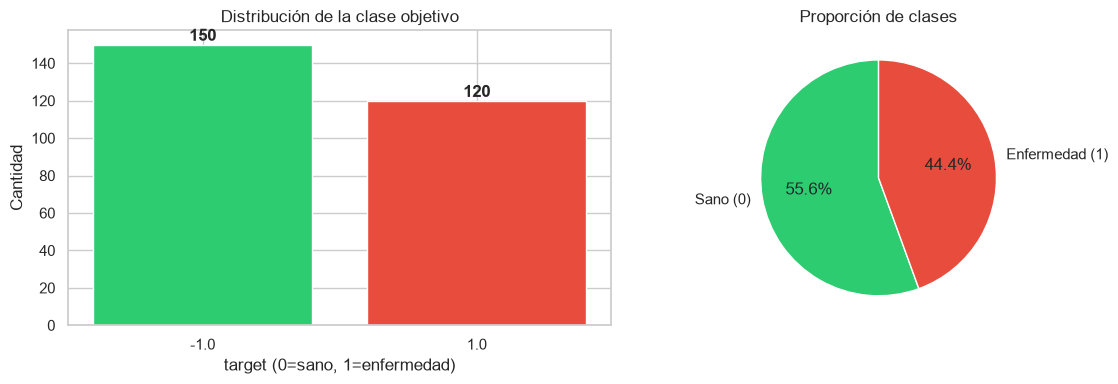

In [6]:
# 3.3  Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
target_counts = df['target'].value_counts()
axes[0].bar(target_counts.index.astype(str), target_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_xlabel('target (0=sano, 1=enfermedad)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Proporción
axes[1].pie(target_counts.values, labels=['Sano (0)', 'Enfermedad (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

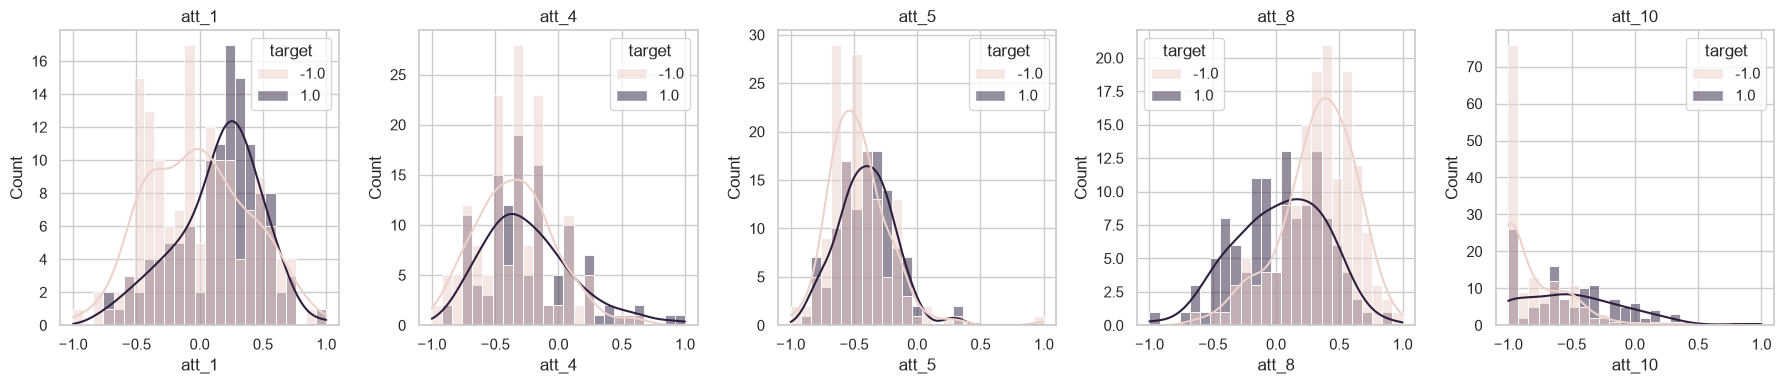

In [7]:
# 3.4  Distribución de variables numéricas clave
# Mapeo de nombres originales a nombres genéricos de OpenML
# 'age' -> 'att_1'
# 'trestbps' -> 'att_4'
# 'chol' -> 'att_5'
# 'thalach' -> 'att_8'
# 'oldpeak' -> 'att_10'
num_cols = ['att_1', 'att_4', 'att_5', 'att_8', 'att_10']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=ax, bins=25)
    ax.set_title(col)
plt.tight_layout()
plt.show()


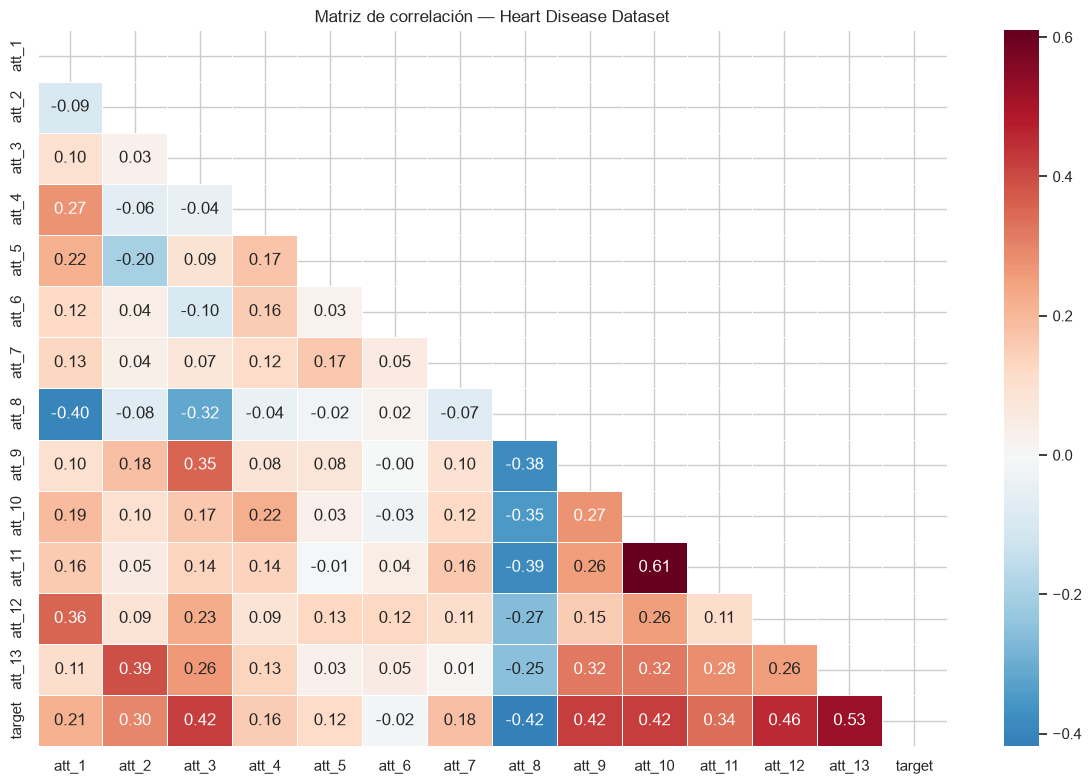

In [8]:
# 3.5  Matriz de correlación
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Matriz de correlación — Heart Disease Dataset')
plt.tight_layout()
plt.show()

#Pearson, correlación entre variables

---
## 4. Etapa 3 — Preparación de datos para el modelado

In [9]:
# 4.1  Separación de features y target
X = df.drop(columns='target')
y = df['target']

print(f'Features: {X.shape}')   # (n_samples, n_features)
print(f'Target:   {y.shape}')   # (n_samples,)

Features: (270, 13)
Target:   (270,)


In [10]:
# 4.2  División train / test (80-20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nProporción target en train:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nProporción target en test:\n{y_test.value_counts(normalize=True).round(3)}')

Train: 216 muestras
Test:  54 muestras

Proporción target en train:
target
-1.0    0.556
 1.0    0.444
Name: proportion, dtype: float64

Proporción target en test:
target
-1.0    0.556
 1.0    0.444
Name: proportion, dtype: float64


---
## 5. Etapa 4 — Entrenamiento de modelos
Entrenamos tres modelos base mediante **pipelines** de Scikit-learn para garantizar un flujo reproducible.

In [11]:
# 5.1  Definición de pipelines
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
        #('clf', LogisticRegression(random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
        #('clf', DecisionTreeClassifier(random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
        #('clf', RandomForestClassifier(random_state=42))
    ])
}


#Definición de la grilla de hiperparámetros para cada modelo
param_grids = {
    'LogisticRegression': {
        'clf__max_iter': [100, 500, 1000] 
    },
    'DecisionTree': {
        'clf__max_depth': [3, 5, 7, 10]
    },
    'RandomForest': {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [5, 7, 10]
    }
}

#Entrenamiento con GridSearchCV
grid_results = {}
for name, pipe in pipelines.items():
    print(f"\nOptimizando {name} con GridSearch...")
    
    # Creamos el buscador GridSearchCV
    grid_search = GridSearchCV(
        estimator=pipe, 
        param_grid=param_grids[name], 
        cv=5, 
        scoring='accuracy',
        n_jobs=-1 # Usar todos los procesadores para acelerar
    )
    
    # Entrenamos el buscador
    grid_search.fit(X_train, y_train)
    
    grid_results[name] = grid_search
    
    print(f"Mejores hiperparámetros: {grid_search.best_params_}")
    print(f"Mejor Accuracy CV: {grid_search.best_score_:.4f}")



#Definición de las distribuciones de hiperparámetros (rangos)
param_distributions = {
    'LogisticRegression': {
        # uniform elige cualquier decimal entre 100 y 1000
        'clf__max_iter': randint(100, 1000) 
    },
    'DecisionTree': {
        # randint elige cualquier número entero entre 3 y 15
        'clf__max_depth': randint(3, 15)
    },
    'RandomForest': {
        'clf__n_estimators': randint(50, 300),
        'clf__max_depth': randint(5, 20)
    }
}

print("\n===================================================")

#Entrenamiento y búsqueda aleatoria
random_results = {}

for name, pipe in pipelines.items():
    print(f"\nOptimizando {name} con RandomizedSearch...")
    
    # Creamos el buscador aleatorio
    random_search = RandomizedSearchCV(
        estimator=pipe, 
        param_distributions=param_distributions[name], 
        n_iter=10,          # LÍMITE: Hará solo 10 intentos al azar por modelo
        cv=5,               # Validación cruzada de 5 bloques
        scoring='accuracy',
        random_state=42,    # Para asegurar que los resultados sean reproducibles
        n_jobs=-1           # Usa todos los núcleos del procesador para que sea más rápido
    )
    
    # Entrenamos el buscador
    random_search.fit(X_train, y_train)
    
    random_results[name] = random_search
    
    print(f"Mejores hiperparámetros: {random_search.best_params_}")
    print(f"Mejor Accuracy CV: {random_search.best_score_:.4f}")

print("\n===================================================")
# 5.2  Entrenamiento y validación cruzada (5-fold)
results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}')

    #75% por encima de ello es buen rendimiento (100% es memorización)


Optimizando LogisticRegression con GridSearch...
Mejores hiperparámetros: {'clf__max_iter': 100}
Mejor Accuracy CV: 0.8288

Optimizando DecisionTree con GridSearch...
Mejores hiperparámetros: {'clf__max_depth': 3}
Mejor Accuracy CV: 0.7685

Optimizando RandomForest con GridSearch...
Mejores hiperparámetros: {'clf__max_depth': 5, 'clf__n_estimators': 200}
Mejor Accuracy CV: 0.8425


Optimizando LogisticRegression con RandomizedSearch...
Mejores hiperparámetros: {'clf__max_iter': 202}
Mejor Accuracy CV: 0.8288

Optimizando DecisionTree con RandomizedSearch...
Mejores hiperparámetros: {'clf__max_depth': 5}
Mejor Accuracy CV: 0.7637

Optimizando RandomForest con RandomizedSearch...
Mejores hiperparámetros: {'clf__max_depth': 11, 'clf__n_estimators': 229}
Mejor Accuracy CV: 0.8288

LogisticRegression         Accuracy CV: 0.8288 ± 0.0682
DecisionTree               Accuracy CV: 0.7637 ± 0.0350
RandomForest               Accuracy CV: 0.8148 ± 0.0390


C:\Users\ANTONY\AppData\Local\Temp\ipykernel_34648\3492203980.py:55: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


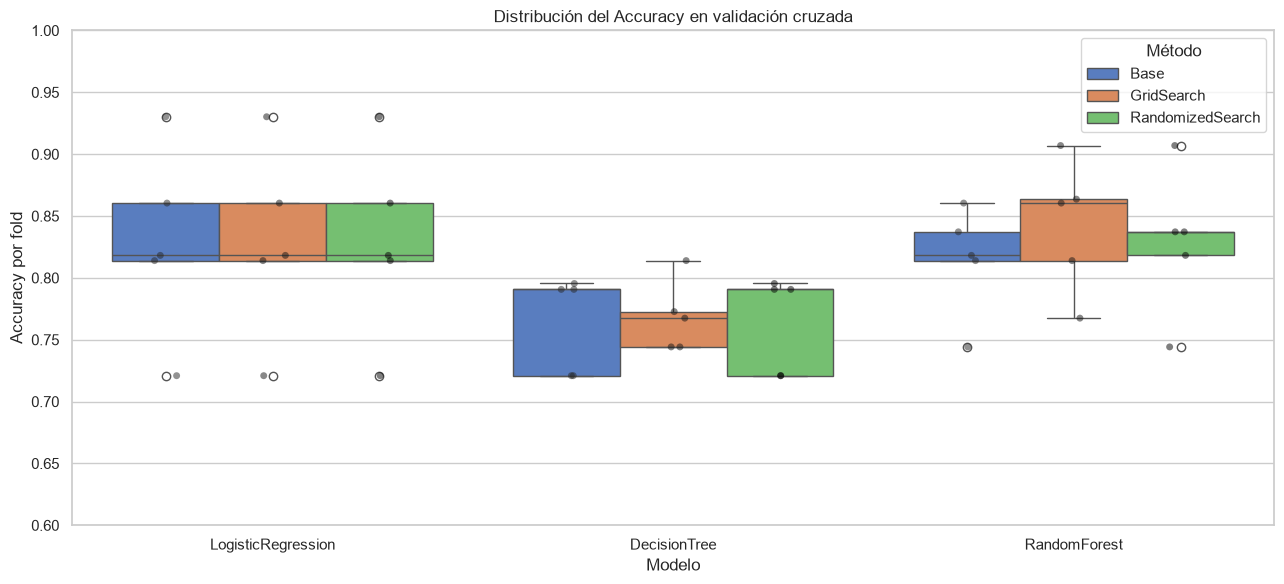

In [12]:
# 5.3 Comparación mediante diagramas de cajas y bigotes

boxplot_data = []

for name in pipelines:

    # Modelo base: cinco resultados de cross-validation
    for fold, score in enumerate(results[name], start=1):
        boxplot_data.append({
            'Modelo': name,
            'Método': 'Base',
            'Fold': fold,
            'Accuracy CV': score
        })

    # Mejor combinación de GridSearchCV
    grid_search = grid_results[name]
    grid_index = grid_search.best_index_

    for fold in range(5):
        boxplot_data.append({
            'Modelo': name,
            'Método': 'GridSearch',
            'Fold': fold + 1,
            'Accuracy CV': grid_search.cv_results_[
                f'split{fold}_test_score'
            ][grid_index]
        })

    # Mejor combinación de RandomizedSearchCV
    random_search = random_results[name]
    random_index = random_search.best_index_

    for fold in range(5):
        boxplot_data.append({
            'Modelo': name,
            'Método': 'RandomizedSearch',
            'Fold': fold + 1,
            'Accuracy CV': random_search.cv_results_[
                f'split{fold}_test_score'
            ][random_index]
        })

boxplot_df = pd.DataFrame(boxplot_data)

plt.figure(figsize=(13, 6))

sns.boxplot(
    data=boxplot_df,
    x='Modelo',
    y='Accuracy CV',
    hue='Método'
)

sns.stripplot(
    data=boxplot_df,
    x='Modelo',
    y='Accuracy CV',
    hue='Método',
    dodge=True,
    color='black',
    alpha=0.5,
    legend=False
)

plt.ylim(0.60, 1.00)
plt.ylabel('Accuracy por fold')
plt.xlabel('Modelo')
plt.title('Distribución del Accuracy en validación cruzada')
plt.legend(title='Método')
plt.tight_layout()
plt.show()

---
## 6. Etapa 5 — Evaluación del mejor modelo

In [13]:
# 6.1  Seleccionar el mejor modelo según CV y entrenar con todo el train set
best_name = max(grid_results,key=lambda name: grid_results[name].best_score_)
best_search = grid_results[best_name]
best_pipeline = best_search.best_estimator_

y_pred = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_name}')
print(f'Mejores hiperparámetros: {best_search.best_params_}')
print(f'Accuracy CV: {best_search.best_score_:.4f}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Sano', 'Enfermedad']))


Mejor modelo: RandomForest
Mejores hiperparámetros: {'clf__max_depth': 5, 'clf__n_estimators': 200}
Accuracy CV: 0.8425
Accuracy en test: 0.8333

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Sano       0.86      0.83      0.85        30
  Enfermedad       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54



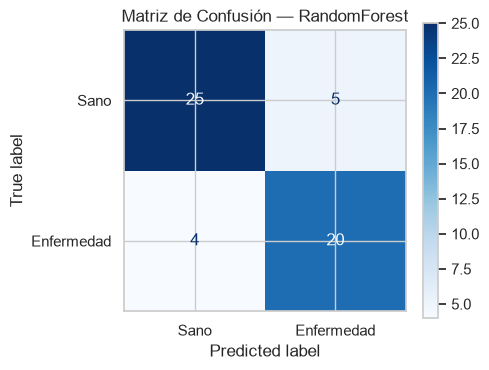

In [14]:
# 6.2  Matriz de confusión, aquí los falsos (los fondo claro)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Sano', 'Enfermedad'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()

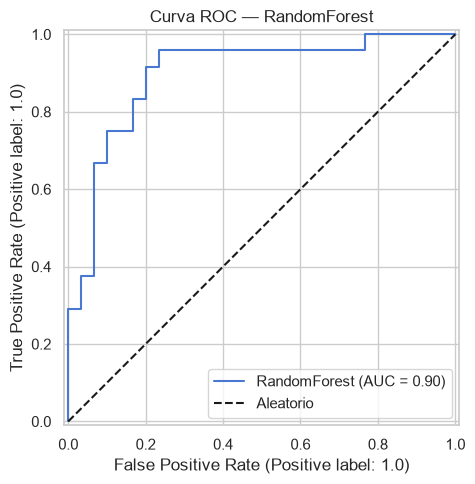

In [15]:
# 6.3  Curva ROC (solo si el modelo soporta predict_proba)
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

#esa linea diagonal es como si mi modelo tuviera un rendimiento del 50%

---
## 7. Etapa 6 — Serialización y despliegue conceptual
Guardamos el pipeline entrenado con `joblib` para simular la etapa de despliegue.

In [16]:
# 7.1  Guardar el modelo
MODEL_PATH = 'heart_disease_model_E1.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

Modelo guardado en: heart_disease_model_E1.joblib


In [17]:
# 7.2  Cargar y verificar el modelo serializado
loaded_model = joblib.load(MODEL_PATH)

# Verificación rápida: misma predicción con datos de test
assert np.array_equal(loaded_model.predict(X_test), y_pred), 'Error: predicciones no coinciden'
print('Verificación OK: el modelo cargado reproduce las predicciones.')

Verificación OK: el modelo cargado reproduce las predicciones.


In [18]:
# 7.3  Función de inferencia (simula un endpoint de predicción)

def predict_heart_disease(patient_data: dict) -> dict:
    """
    Recibe un diccionario con los features del paciente
    y retorna la predicción y la probabilidad.
    """
    model = joblib.load(MODEL_PATH)

    # Mapeo de nombres originales a nombres genéricos de OpenML
    feature_name_map = {
        'age': 'att_1',
        'sex': 'att_2',
        'cp': 'att_3',
        'trestbps': 'att_4',
        'chol': 'att_5',
        'fbs': 'att_6',
        'restecg': 'att_7',
        'thalach': 'att_8',
        'exang': 'att_9',
        'oldpeak': 'att_10',
        'slope': 'att_11',
        'ca': 'att_12',
        'thal': 'att_13'
    }

    # Renombrar las claves en patient_data y asegurar el orden correcto de las columnas
    # 'feature_names' es una variable global del kernel que contiene el orden correcto de las columnas
    # (e.g., ['att_1', 'att_2', ..., 'att_13'])
    try:
        renamed_patient_data_ordered = {feature_name_map[k]: patient_data[k] for k in feature_name_map.keys()}
        ordered_values = [renamed_patient_data_ordered[name] for name in feature_names]
        input_df = pd.DataFrame([ordered_values], columns=feature_names)
    except KeyError as e:
        raise ValueError(f"Missing or incorrect feature name in patient_data: {e}. Expected descriptive names from the mapping.")

    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]

    # Ajustar etiquetas de predicción según las clases del modelo (-1.0 y 1.0)
    prediction_label = 'Enfermedad cardíaca' if pred == 1.0 else 'Sano'

    # Asumiendo que proba[0] es para la clase -1.0 (Sano) y proba[1] para 1.0 (Enfermedad)
    return {
        'prediccion': prediction_label,
        'probabilidad_enfermedad': round(float(proba[1]), 4),
        'probabilidad_sano': round(float(proba[0]), 4)
    }

# Ejemplo de uso con un paciente ficticio
paciente_ejemplo = {
    'age': 55, 'sex': 1, 'cp': 2, 'trestbps': 140,
    'chol': 250, 'fbs': 0, 'restecg': 1, 'thalach': 150,
    'exang': 0, 'oldpeak': 1.5, 'slope': 1, 'ca': 0, 'thal': 2
}

resultado = predict_heart_disease(paciente_ejemplo)
print('\n--- Resultado de inferencia ---')
for k, v in resultado.items():
    print(f'  {k}: {v}')


--- Resultado de inferencia ---
  prediccion: Enfermedad cardíaca
  probabilidad_enfermedad: 0.7701
  probabilidad_sano: 0.2299


---
## 8. Resumen del ciclo de vida recorrido

| Etapa | Qué hicimos | Herramientas |
|---|---|---|
| **Recolección** | Descarga del dataset Heart Disease (UCI/OpenML) | `pandas`, URL pública |
| **Exploración** | Análisis de distribuciones, correlaciones, nulos | `seaborn`, `matplotlib` |
| **Preparación** | Limpieza, split estratificado 80/20 | `train_test_split` |
| **Entrenamiento** | 3 modelos con pipelines + validación cruzada 5-fold | `Pipeline`, `cross_val_score` |
| **Evaluación** | Accuracy, precision, recall, F1, ROC, matriz confusión | `classification_report`, `RocCurveDisplay` |
| **Despliegue** | Serialización con joblib + función de inferencia | `joblib` |

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*

---
---

# Ejercicio 2 — Ciclo de Vida de ML aplicado a Parkinson's Disease

A continuación se repite el mismo ciclo de vida de 6 etapas (configuración, recolección, exploración, preparación, entrenamiento, evaluación y despliegue), esta vez aplicado al dataset **Parkinson's Disease Data Set** (Kaggle/UCI). La numeración de secciones vuelve a empezar en 1 porque es un ciclo de vida completo e independiente del Ejercicio 1.

# Sesión 01 — Ciclo de Vida de Machine Learning
**Curso:** Ingeniería del Conocimiento (ISO56B)
**Dataset:** Parkinson's Disease Data Set (Kaggle / UCI)
**Alumno:** Morales Valverde Antony Rodrigo
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú

---

## Objetivo
Replicar el ciclo de vida completo de un proyecto de Machine Learning visto en clase —desde la recolección de datos hasta la evaluación y serialización del modelo— aplicándolo al dataset **Parkinson's Disease**, para predecir si una persona tiene la enfermedad (`status = 1`) o no (`status = 0`) a partir de mediciones acústicas de la voz.

## 1. Configuración del entorno
Instalamos/importamos las librerías necesarias. En Google Colab la mayoría ya están disponibles.

In [19]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Etapa 1 — Recolección de datos
Descargamos el **Parkinson's Disease dataset** desde Kaggle con `kagglehub`. Si el paquete no está disponible o falla la descarga, usamos la copia local `parkinsons.data`.

| Variable | Descripción |
|---|---|
| `name` | Identificador de la grabación (paciente + intento) — no es un feature |
| `MDVP:Fo(Hz)` | Frecuencia fundamental promedio de la voz |
| `MDVP:Fhi(Hz)` | Frecuencia fundamental máxima |
| `MDVP:Flo(Hz)` | Frecuencia fundamental mínima |
| `MDVP:Jitter(%)`, `Jitter(Abs)`, `RAP`, `PPQ`, `DDP` | Medidas de variación de frecuencia (jitter) |
| `MDVP:Shimmer`, `Shimmer(dB)`, `APQ3`, `APQ5`, `APQ`, `DDA` | Medidas de variación de amplitud (shimmer) |
| `NHR`, `HNR` | Relación ruido/armónicos en la voz |
| `RPDE`, `D2` | Medidas no lineales de dinámica de la señal |
| `DFA` | Exponente de tendencia fractal de la señal |
| `spread1`, `spread2`, `PPE` | Medidas no lineales de variación de frecuencia fundamental |
| `status` | Diagnóstico (1 = Parkinson, 0 = sano) — **variable objetivo** |

In [20]:
# Intentamos descargar el dataset desde Kaggle con kagglehub
try:
    import kagglehub
    path = kagglehub.dataset_download("vikasukani/parkinsons-disease-data-set")
    print(f'Dataset descargado en: {path}')
    df = pd.read_csv(f'{path}/parkinsons.data')
    print(f'Dataset cargado desde Kaggle — {df.shape[0]} registros, {df.shape[1]} columnas')
except Exception as e:
    print(f'No se pudo descargar desde Kaggle: {e}')
    print('Cargando copia local parkinsons.data ...')
    df = pd.read_csv('parkinsons.data')
    print(f'Dataset cargado localmente — {df.shape[0]} registros, {df.shape[1]} columnas')

df.head()

c:\Users\ANTONY\Documents\ANTONY\ACADÉMICO\CARRERA\5 - QUINTO CICLO\INGENIERÍA DEL CONOCIMIENTO\Work Environment_IDC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset descargado en: C:\Users\ANTONY\.cache\kagglehub\datasets\vikasukani\parkinsons-disease-data-set\versions\1
Dataset cargado desde Kaggle — 195 registros, 24 columnas


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


---
## 3. Etapa 2 — Exploración y preparación de datos

In [21]:
# 3.1  Información general del dataset
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()
print('\n')
df.describe().round(2)

INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    str    
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null 

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.00,195.00,195.00,195.00,195.0,195.00,195.00,195.00,195.00,195.00,...,195.00,195.00,195.00,195.00,195.00,195.00,195.00,195.00,195.00,195.00
mean,154.23,197.10,116.32,0.01,0.0,0.00,0.00,0.01,0.03,0.28,...,0.05,0.02,21.89,0.75,0.50,0.72,-5.68,0.23,2.38,0.21
std,41.39,91.49,43.52,0.00,0.0,0.00,0.00,0.01,0.02,0.19,...,0.03,0.04,4.43,0.43,0.10,0.06,1.09,0.08,0.38,0.09
min,88.33,102.14,65.48,0.00,0.0,0.00,0.00,0.00,0.01,0.08,...,0.01,0.00,8.44,0.00,0.26,0.57,-7.96,0.01,1.42,0.04
25%,117.57,134.86,84.29,0.00,0.0,0.00,0.00,0.00,0.02,0.15,...,0.02,0.01,19.20,1.00,0.42,0.67,-6.45,0.17,2.10,0.14
50%,148.79,175.83,104.32,0.00,0.0,0.00,0.00,0.01,0.02,0.22,...,0.04,0.01,22.08,1.00,0.50,0.72,-5.72,0.22,2.36,0.19
75%,182.77,224.21,140.02,0.01,0.0,0.00,0.00,0.01,0.04,0.35,...,0.06,0.03,25.08,1.00,0.59,0.76,-5.05,0.28,2.64,0.25
max,260.10,592.03,239.17,0.03,0.0,0.02,0.02,0.06,0.12,1.30,...,0.17,0.31,33.05,1.00,0.69,0.83,-2.43,0.45,3.67,0.53


In [22]:
# 3.2  Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

# Eliminar duplicados si existen
df = df.drop_duplicates().reset_index(drop=True)
print(f'Registros después de limpieza: {df.shape[0]}')

Valores nulos por columna:
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

Registros duplicados: 0
Registros después de limpieza: 195


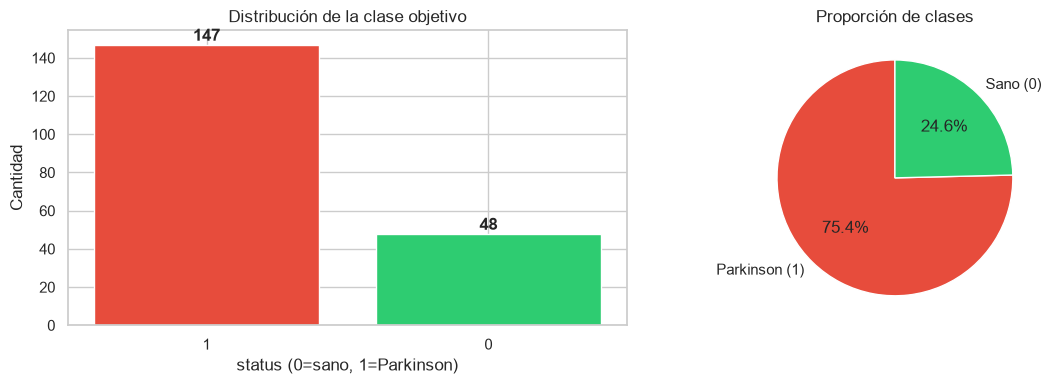

In [23]:
# 3.3  Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
target_counts = df['status'].value_counts()
axes[0].bar(target_counts.index.astype(str), target_counts.values,
            color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_xlabel('status (0=sano, 1=Parkinson)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Proporción
axes[1].pie(target_counts.values, labels=['Parkinson (1)', 'Sano (0)'] if target_counts.index[0]==1 else ['Sano (0)', 'Parkinson (1)'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()


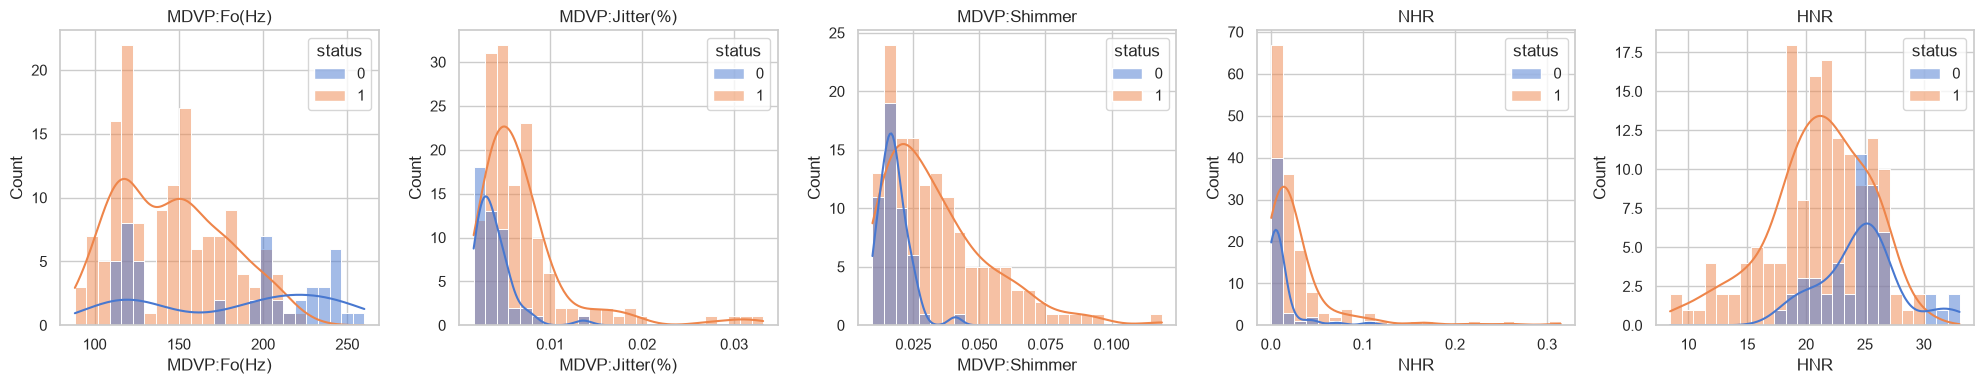

In [24]:
# 3.4  Distribución de variables numéricas clave
# Aquí sí tenemos los nombres reales de las columnas
num_cols = ['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer', 'NHR', 'HNR']

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='status', kde=True, ax=ax, bins=25)
    ax.set_title(col)
plt.tight_layout()
plt.show()


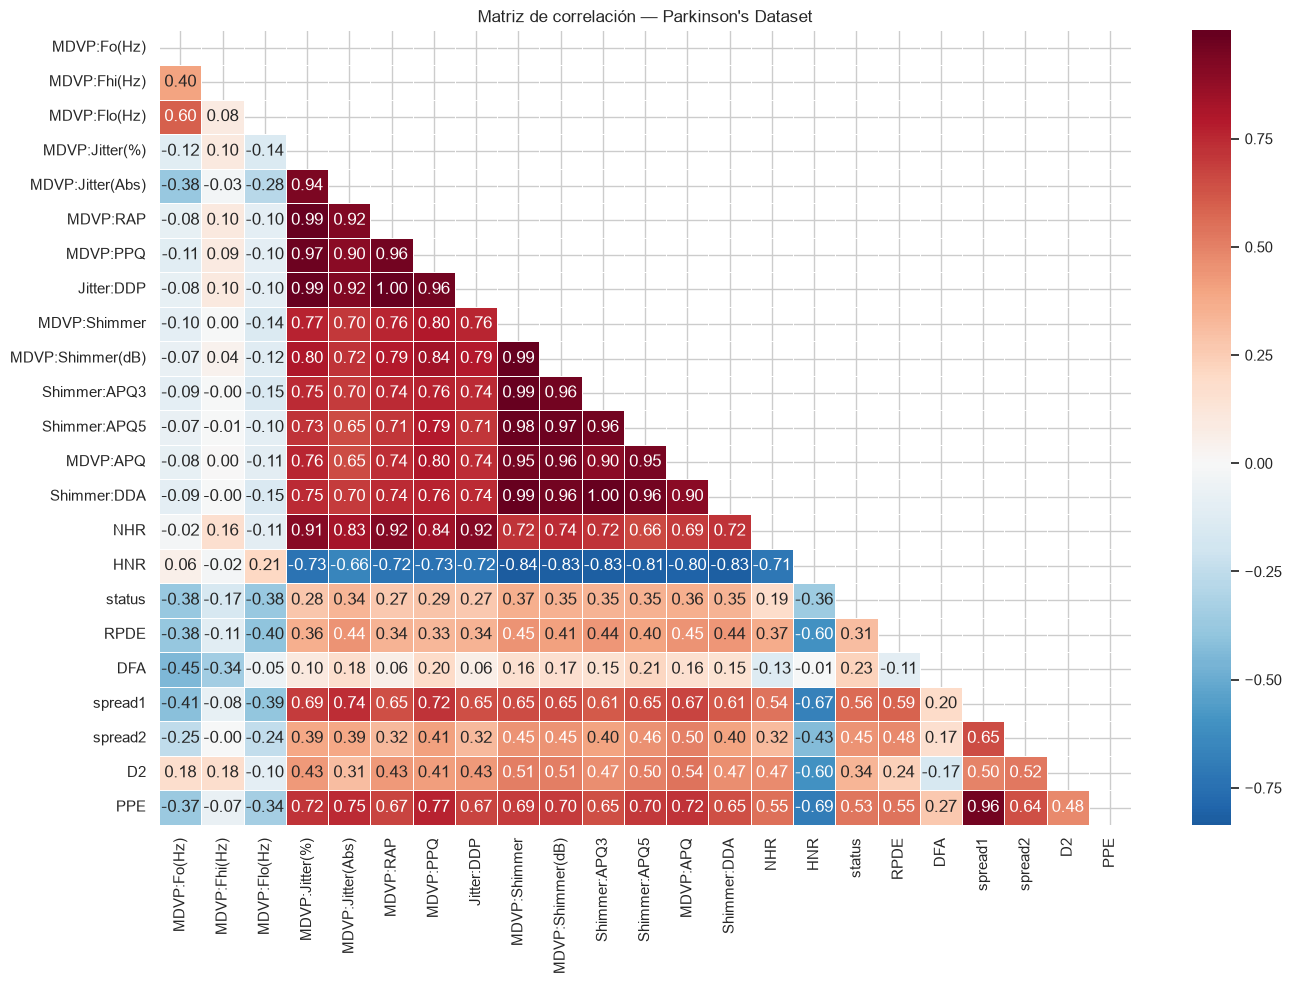

In [25]:
# 3.5  Matriz de correlación
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Matriz de correlación — Parkinson\'s Dataset')
plt.tight_layout()
plt.show()

#Pearson, correlación entre variables

---
## 4. Etapa 3 — Preparación de datos para el modelado

In [26]:
# 4.1  Separación de features y target

X = df.drop(columns=['status', 'name'])
y = df['status']

feature_names = X.columns.tolist()

print(f'Features: {X.shape}')   # (n_samples, n_features)
print(f'Target:   {y.shape}')   # (n_samples,)

Features: (195, 22)
Target:   (195,)


In [27]:
# 4.2  División train / test (80-20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nProporción target en train:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nProporción target en test:\n{y_test.value_counts(normalize=True).round(3)}')

Train: 156 muestras
Test:  39 muestras

Proporción target en train:
status
1    0.756
0    0.244
Name: proportion, dtype: float64

Proporción target en test:
status
1    0.744
0    0.256
Name: proportion, dtype: float64


---
## 5. Etapa 4 — Entrenamiento de modelos
Entrenamos tres modelos base mediante **pipelines** de Scikit-learn para garantizar un flujo reproducible.

In [28]:
# 5.1  Definición de pipelines
pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
    ])
}

# 5.2  Entrenamiento y validación cruzada (5-fold)
results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}')

    #75% por encima de ello es buen rendimiento (100% es memorización)

LogisticRegression         Accuracy CV: 0.8335 ± 0.0550
DecisionTree               Accuracy CV: 0.8724 ± 0.0515
RandomForest               Accuracy CV: 0.8978 ± 0.0361


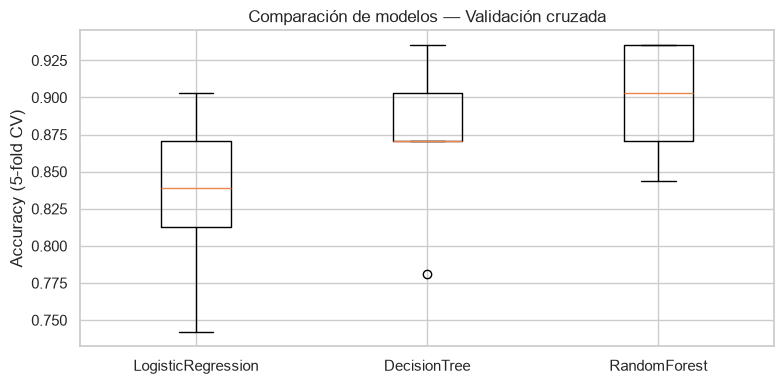

In [29]:
# 5.3  Comparación visual de modelos
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(list(results.values()), tick_labels=list(results.keys()))
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Comparación de modelos — Validación cruzada')
plt.tight_layout()
plt.show()

---
## 6. Etapa 5 — Evaluación del mejor modelo

In [30]:
# 6.1  Seleccionar el mejor modelo según CV y entrenar con todo el train set
best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_name}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Sano', 'Parkinson']))

'''
Al estar las clases desbalanceadas (más casos de Parkinson que sanos),
hay que fijarse bien en el recall de la clase "Sano": un modelo perezoso
podría "acertar mucho" solo por predecir casi siempre "Parkinson".
Falso positivo: persona sana, le decimos que tiene Parkinson
Falso negativo: persona con Parkinson, le decimos que está sana (el más grave aquí)
'''

Mejor modelo: RandomForest
Accuracy en test: 0.9231

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Sano       0.89      0.80      0.84        10
   Parkinson       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



'\nAl estar las clases desbalanceadas (más casos de Parkinson que sanos),\nhay que fijarse bien en el recall de la clase "Sano": un modelo perezoso\npodría "acertar mucho" solo por predecir casi siempre "Parkinson".\nFalso positivo: persona sana, le decimos que tiene Parkinson\nFalso negativo: persona con Parkinson, le decimos que está sana (el más grave aquí)\n'

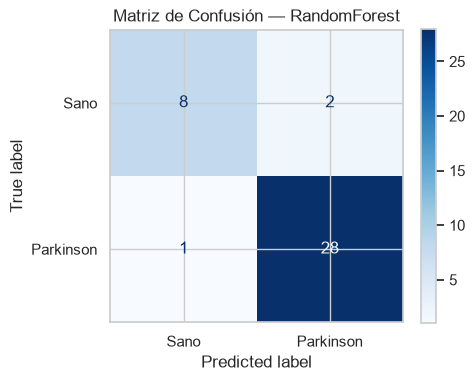

In [31]:
# 6.2  Matriz de confusión, aquí los falsos (los fondo claro)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Sano', 'Parkinson'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()

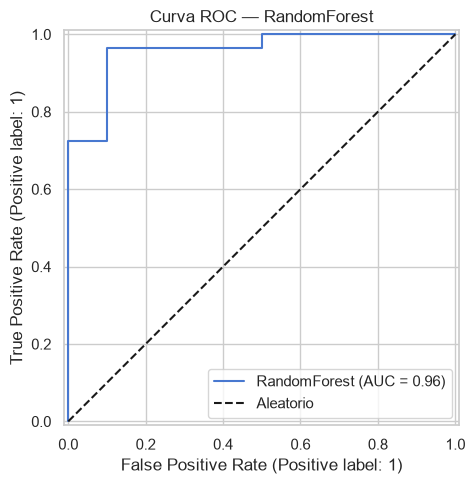

In [32]:
# 6.3  Curva ROC (solo si el modelo soporta predict_proba)
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

#esa linea diagonal es como si mi modelo tuviera un rendimiento del 50%

---
## 7. Etapa 6 — Serialización y despliegue conceptual
Guardamos el pipeline entrenado con `joblib` para simular la etapa de despliegue.

In [33]:
# 7.1  Guardar el modelo
MODEL_PATH = 'parkinsons_model.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

Modelo guardado en: parkinsons_model.joblib


In [34]:
# 7.2  Cargar y verificar el modelo serializado
loaded_model = joblib.load(MODEL_PATH)

# Verificación rápida: misma predicción con datos de test
assert np.array_equal(loaded_model.predict(X_test), y_pred), 'Error: predicciones no coinciden'
print('Verificación OK: el modelo cargado reproduce las predicciones.')

Verificación OK: el modelo cargado reproduce las predicciones.


In [35]:
# 7.3  Función de inferencia (simula un endpoint de predicción)

def predict_parkinsons(patient_data: dict) -> dict:
    """
    Recibe un diccionario con las mediciones de voz del paciente
    (usando los nombres reales de columnas, ej. 'MDVP:Fo(Hz)')
    y retorna la predicción y la probabilidad.
    """
    model = joblib.load(MODEL_PATH)

    try:
        ordered_values = [patient_data[name] for name in feature_names]
        input_df = pd.DataFrame([ordered_values], columns=feature_names)
    except KeyError as e:
        raise ValueError(f"Falta el feature {e} en patient_data.")

    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0] if hasattr(model, 'predict_proba') else None

    prediction_label = 'Parkinson' if pred == 1 else 'Sano'

    resultado: dict[str, str | float] = {'prediccion': prediction_label}
    if proba is not None:
        resultado['probabilidad_parkinson'] = round(float(proba[1]), 4)
        resultado['probabilidad_sano'] = round(float(proba[0]), 4)
    return resultado

paciente_ejemplo_ficticio = {
    'MDVP:Fo(Hz)': 120.0,
    'MDVP:Fhi(Hz)': 140.0,
    'MDVP:Flo(Hz)': 110.0,
    'MDVP:Jitter(%)': 0.0065,
    'MDVP:Jitter(Abs)': 0.00005,
    'MDVP:RAP': 0.0035,
    'MDVP:PPQ': 0.0038,
    'Jitter:DDP': 0.0105,
    'MDVP:Shimmer': 0.035,
    'MDVP:Shimmer(dB)': 0.32,
    'Shimmer:APQ3': 0.018,
    'Shimmer:APQ5': 0.021,
    'MDVP:APQ': 0.025,
    'Shimmer:DDA': 0.054,
    'NHR': 0.025,
    'HNR': 21.0,
    'RPDE': 0.52,
    'DFA': 0.72,
    'spread1': -0.30,
    'spread2': 0.20,
    'D2': 2.30,
    'PPE': 0.22
}

resultado = predict_parkinsons(paciente_ejemplo_ficticio)
print('\n--- Resultado de inferencia ---')
for k, v in resultado.items():
    print(f'  {k}: {v}')
print(f'\n  (Valor real: {"Parkinson" if y_test.iloc[0] == 1 else "Sano"})')


--- Resultado de inferencia ---
  prediccion: Parkinson
  probabilidad_parkinson: 1.0
  probabilidad_sano: 0.0

  (Valor real: Sano)


---
## 8. Resumen del ciclo de vida recorrido

| Etapa | Qué hicimos | Herramientas |
|---|---|---|
| **Recolección** | Descarga del dataset Parkinson's (Kaggle vía `kagglehub`, con respaldo local) | `kagglehub`, `pandas` |
| **Exploración** | Análisis de distribuciones, correlaciones, nulos, desbalance de clases | `seaborn`, `matplotlib` |
| **Preparación** | Limpieza, descarte de `name`, split estratificado 80/20 | `train_test_split` |
| **Entrenamiento** | 3 modelos con pipelines + validación cruzada 5-fold | `Pipeline`, `cross_val_score` |
| **Evaluación** | Accuracy, precision, recall, F1, ROC, matriz confusión | `classification_report`, `RocCurveDisplay` |
| **Despliegue** | Serialización con joblib + función de inferencia | `joblib` |

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*
*Ejercicio 2 — Nuevo dataset, mismo pipeline (Parkinson's Disease Data Set)*